# 01b · EDA Ek Analizleri (Addendum)

`hakan/notebooks/01_eda.ipynb`'yi **tamamlayan** ek analizler. O notebook'taki bulgular geçerli; burada eksik kalan veya
düzeltilmesi gereken noktalar, ders içerikleriyle (BBM416, AIN431, AIN420) ilişkilendirilerek ele alınıyor.

**Öne çıkan bulgular**
1. **Sınıf dağılımı çözünürlüğe (ve aydınlatmaya) göre çok değişiyor.** 1400×788 görüntülerde `bus` payı diğer gruplardan ~6 kat fazla
   ve bu grup testin %44'ü. Ancak testteki 1400×788 görüntülerin **%45'i karanlık** (train'de %18) ve karanlık karelerde bus/van daha az.
   → Testte `bus` payının train'den yüksek olması bekleniyor. Val metriği **çözünürlük × aydınlatma katmanlarına göre ağırlıklandırılmalı.**
2. **Perspektif etkisi güçlü:** nesne boyutu görüntünün üstünden altına doğru ~2,3 kat artıyor → `flipud` kullanılmamalı.
3. **Küçük kutularda IoU çok hassas:** 14×14 bir kutu çapraz 3 px kayınca IoU < 0,5.
4. Resize analizi Ultralytics'in **büyütme** davranışıyla yeniden hesaplandı. Test ağırlığıyla sonuç train'e çok yakın (2000×1500 testte yok).
5. **Test daha karanlık** (train %15 → test %22), fark neredeyse tamamen **1400×788** grubundan geliyor (%18 → %45).
6. **Sızma yok:** neredeyse aynı kare oranı çok düşük → rastgele split geçerli.
7. Etiket tutarlılığı: birkaç car↔van çift etiketi (ihmal edilebilir).

**Çıktı:** `furkan/val_test_weights.csv` → yerel değerlendiricinin kullanacağı test-ağırlıklı val görüntü ağırlıkları
ve alt küme bayrakları. Aynı dosyada ağırlıklı AP için referans fonksiyon (Bölüm B) test edildi.

**İçindekiler**
0. Kurulum ve önbellekli görüntü özellikleri
A. Sınıf dağılımı × çözünürlük ve beklenen test dağılımı
B. Test-ağırlıklı validation metriği
C. Perspektif: nesne boyutu ve dikey konum
D. Küçük kutularda IoU hassasiyeti
E. Resize analizi (düzeltilmiş)
F. Aydınlatma: train ve test
G. Sızma (leakage) kontrolü
H. Etiket tutarlılığı
I. Bulgular → Kararlar

## 0. Kurulum

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image


def find_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "train" / "annotations.csv").exists():
            return p
    raise FileNotFoundError("data/train/annotations.csv bulunamadı")


ROOT = find_root()
DATA = ROOT / "data"
SPLITS = ROOT / "splits"
TRAIN_IMG_DIR = DATA / "train" / "images"
TEST_IMG_DIR = DATA / "test" / "images"
CACHE = DATA / "cache"          # data/ git dışında: önbellek buraya
CACHE.mkdir(exist_ok=True)
OUT_DIR = ROOT / "furkan"

CLASSES = ["car", "van", "truck", "bus"]
CLASS_COLORS = {"car": "#2a78d6", "van": "#eb6834", "truck": "#1baf7a", "bus": "#eda100"}   # 01_eda ile aynı
SPLIT_COLORS = {"train": "#52514e", "val": "#9a9994", "test": "#4a3aa7"}
MIN_AREA = 200
SEED = 42
DARK_THR = 60        # ortalama parlaklık < 60 → karanlık görüntü (gece / düşük ışık)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": "#c9c8c2", "axes.titleweight": "bold",
    "axes.titlesize": 12, "grid.color": "#ecebe7",
    "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.float_format", "{:,.2f}".format)
print("Repo kökü:", ROOT)

Repo kökü: /sessions/rcw-01syzqzyyhajx2xdm9svz9z8/mnt/roketsan-hackathon


Görüntü boyutu, parlaklık ve **dHash** (algısal özet; bkz. Bölüm G) her görüntü için bir kez hesaplanıp
`data/cache/` altında saklanıyor. `Image.draft` ile JPEG küçük ölçekte çözüldüğü için hızlı.

In [2]:
def dhash_hex(gray: Image.Image, size: int = 8) -> str:
    # Fark özeti: komşu piksellerin parlaklık karşılaştırmasından 64 bitlik parmak izi
    s = np.asarray(gray.resize((size + 1, size), Image.BILINEAR), dtype=np.int16)
    bits = (s[:, 1:] > s[:, :-1]).flatten()
    return f"{int(''.join('1' if b else '0' for b in bits), 2):016x}"


def image_features(folder: Path, split: str) -> pd.DataFrame:
    rows = []
    for p in sorted(folder.glob("*.jpg")):
        with Image.open(p) as im:
            w, h = im.size                      # draft'tan ÖNCE gerçek boyut
            im.draft("L", (160, 120))
            g = im.convert("L")
            arr = np.asarray(g, dtype=np.float32)
            rows.append({"image_id": p.stem, "split": split, "width": w, "height": h,
                         "brightness": float(arr.mean()), "contrast": float(arr.std()),
                         "dhash": dhash_hex(g)})
    return pd.DataFrame(rows)


FEAT_CSV = CACHE / "image_features_v1.csv"
if FEAT_CSV.exists():
    meta = pd.read_csv(FEAT_CSV, dtype={"dhash": str})
else:
    meta = pd.concat([image_features(TRAIN_IMG_DIR, "train"),
                      image_features(TEST_IMG_DIR, "test")], ignore_index=True)
    meta.to_csv(FEAT_CSV, index=False)

tr_ids = set((SPLITS / "train.txt").read_text().split())
va_ids = set((SPLITS / "val.txt").read_text().split())
meta["subset"] = np.where(meta["split"] == "test", "test",
                          np.where(meta["image_id"].isin(va_ids), "val", "train"))
meta["resolution"] = meta["width"].astype(str) + "×" + meta["height"].astype(str)
meta["is_dark"] = meta["brightness"] < DARK_THR
meta["stratum"] = meta["resolution"] + " · " + np.where(meta["is_dark"], "karanlık", "aydınlık")

ann_raw = pd.read_csv(DATA / "train" / "annotations.csv")
ann = ann_raw.drop_duplicates().copy()
ann = ann.merge(meta[["image_id", "width", "height", "resolution", "subset", "is_dark", "stratum"]], on="image_id", how="left")
ann["area"] = ann["w"] * ann["h"]
ann["side"] = np.sqrt(ann["area"])
ann["min_side"] = ann[["w", "h"]].min(axis=1)
ann["cy"] = (ann["y"] + ann["h"] / 2) / ann["height"]

print(f"Tekrar eden satır atıldı: {len(ann_raw) - len(ann)}  |  kutu: {len(ann):,}  |  görüntü: {len(meta):,}")
meta["subset"].value_counts().to_frame("görüntü")

Tekrar eden satır atıldı: 1  |  kutu: 165,348  |  görüntü: 8,589


,görüntü
subset,
train,5177
test,2118
val,1294


## A. Sınıf dağılımı × çözünürlük

01_eda sınıf dağılımını ve çözünürlük dağılımını **ayrı ayrı** inceledi. Test dağılımı train'den farklı olduğu için asıl soru şu:
**sınıf oranları çözünürlüğe göre değişiyor mu?** Değişiyorsa testteki sınıf karışımı da train'den farklı olur.

In [3]:
train_all = meta[meta["split"] == "train"]
n_img = train_all["resolution"].value_counts()
p_train = train_all["resolution"].value_counts(normalize=True)
p_test = meta[meta["split"] == "test"]["resolution"].value_counts(normalize=True)

RES = [r for r in p_train.index if n_img[r] >= 100]          # yeterli örneği olan gruplar
RES = sorted(RES, key=lambda r: -p_test.get(r, 0))           # testteki paya göre sırala

mix = pd.crosstab(ann["resolution"], ann["label"], normalize="index").reindex(RES)[CLASSES] * 100
res_tab = mix.round(1).copy()
res_tab["kutu/görüntü"] = (ann.groupby("resolution").size() / n_img).reindex(RES).round(1)
res_tab["medyan alan"] = ann.groupby("resolution")["area"].median().reindex(RES)
res_tab["<32² (%)"] = (ann.assign(s=ann["area"] < 32**2).groupby("resolution")["s"].mean().reindex(RES) * 100).round(1)
res_tab["train görüntü %"] = (p_train.reindex(RES) * 100).round(1)
res_tab["test görüntü %"] = (p_test.reindex(RES).fillna(0) * 100).round(1)
res_tab

label,car,van,truck,bus,kutu/görüntü,medyan alan,<32² (%),train görüntü %,test görüntü %
resolution,,,,,,,,,
1400×788,60.40,19.70,9.30,10.60,24.50,"1,170.00",45.90,20.10,44.10
1360×765,78.40,12.40,7.60,1.60,28.70,"1,296.00",42.50,11.50,26.30
1400×1050,80.80,10.50,7.00,1.70,24.20,"1,798.00",35.80,38.60,12.90
960×540,77.60,11.70,9.30,1.40,11.40,701.00,62.80,3.90,7.30
1916×1078,73.70,13.90,10.90,1.40,17.10,"2,205.00",28.50,8.30,7.10
1920×1080,83.40,9.70,3.70,3.10,39.40,"1,344.00",42.20,5.20,2.40
2000×1500,75.60,17.50,6.00,0.90,32.90,"2,352.00",28.50,11.90,0.00


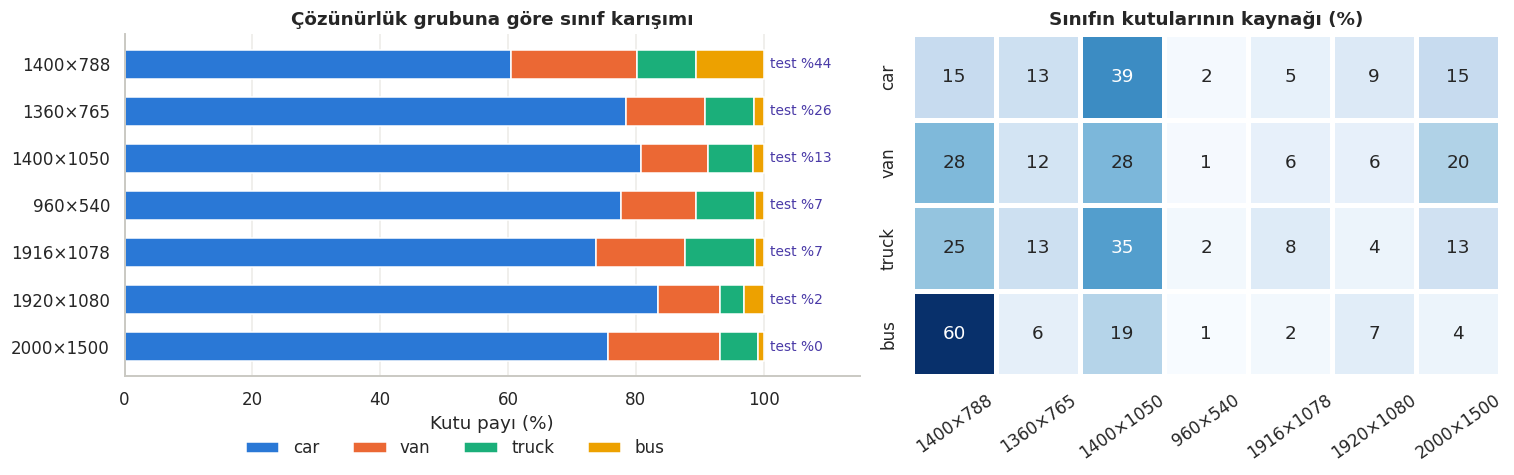

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1.25, 1]})

left = np.zeros(len(RES))
for c in CLASSES:
    axes[0].barh(RES, mix[c], left=left, color=CLASS_COLORS[c], label=c, height=0.62)
    left += mix[c].values
for i, r in enumerate(RES):
    axes[0].text(101, i, f"test %{p_test.get(r, 0) * 100:.0f}", va="center", fontsize=9, color=SPLIT_COLORS["test"])
axes[0].invert_yaxis()
axes[0].set_xlim(0, 115)
axes[0].set_xlabel("Kutu payı (%)")
axes[0].set_title("Çözünürlük grubuna göre sınıf karışımı")
axes[0].legend(frameon=False, ncol=4, loc="lower center", bbox_to_anchor=(0.45, -0.28))
axes[0].grid(axis="y", visible=False)

# Her sınıfın kutularının hangi çözünürlükten geldiği
src = pd.crosstab(ann["label"], ann["resolution"], normalize="index").reindex(CLASSES)[RES] * 100
sns.heatmap(src, annot=True, fmt=".0f", cmap="Blues", cbar=False, linewidths=2, linecolor="white", ax=axes[1])
axes[1].set_title("Sınıfın kutularının kaynağı (%)")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

**Aydınlatma da sınıf karışımını değiştiriyor.** Testte en çok görülen 1400×788 grubunu karanlık/aydınlık diye ayıralım
(eşik: ortalama parlaklık < 60, bkz. Bölüm F).

In [5]:
g788 = ann[ann["resolution"] == "1400×788"]
img788 = meta[(meta["split"] == "train") & (meta["resolution"] == "1400×788")]
t788 = meta[(meta["split"] == "test") & (meta["resolution"] == "1400×788")]
dark_mix = pd.crosstab(g788["is_dark"], g788["label"], normalize="index")[CLASSES] * 100
dark_mix["kutu/görüntü"] = g788.groupby("is_dark").size() / img788.groupby("is_dark").size()
dark_mix["train görüntü %"] = img788["is_dark"].value_counts(normalize=True) * 100
dark_mix["test görüntü %"] = t788["is_dark"].value_counts(normalize=True) * 100
dark_mix.index = dark_mix.index.map({False: "aydınlık", True: "karanlık"})
dark_mix.round(1)

label,car,van,truck,bus,kutu/görüntü,train görüntü %,test görüntü %
is_dark,,,,,,,
aydınlık,58.80,20.90,9.40,10.90,26.90,81.70,54.90
karanlık,73.80,9.40,9.00,7.80,13.90,18.30,45.10


**Beklenen test sınıf dağılımı.** Varsayım: her katmanın (*çözünürlük × aydınlatma*) kendi içindeki sınıf oranı ve kutu yoğunluğu testte de aynı.
Testteki beklenen kutu payı katmanlar üzerinden `test görüntü payı × kutu/görüntü × sınıf payı` ile hesaplanır.
Karşılaştırma için yalnızca çözünürlüğe göre yapılan (daha kaba) tahmini de gösteriyoruz.

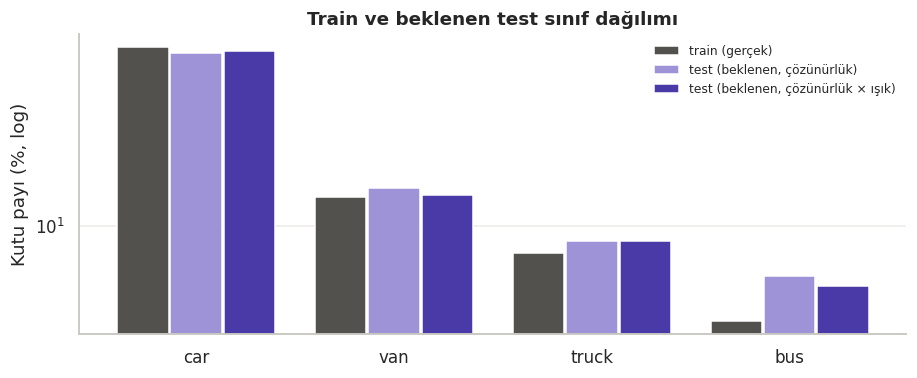

,train kutu %,beklenen test % (çözünürlük),beklenen test % (çözünürlük × ışık),oran (test/train)
label,,,,
car,75.50,70.67,72.38,0.96
van,13.78,15.34,14.19,1.03
truck,7.32,8.36,8.37,1.14
bus,3.39,5.63,5.06,1.49


In [6]:
def expected_test_mix(key):
    tr = meta[meta["split"] == "train"]
    te_share = meta[meta["split"] == "test"][key].value_counts(normalize=True)
    dens = ann.groupby(key).size() / tr[key].value_counts()
    mix_k = pd.crosstab(ann[key], ann["label"], normalize="index")[CLASSES]
    # train'de karşılığı olmayan test katmanı → aynı çözünürlüğün genel oranı (yedek)
    miss = [k for k in te_share.index if k not in mix_k.index]
    assert not miss, f"Train'de olmayan test katmanı: {miss}"
    counts = sum(te_share[k] * dens[k] * mix_k.loc[k] for k in te_share.index)
    return counts / counts.sum() * 100

expected = pd.DataFrame({
    "train kutu %": ann["label"].value_counts(normalize=True).reindex(CLASSES) * 100,
    "beklenen test % (çözünürlük)": expected_test_mix("resolution"),
    "beklenen test % (çözünürlük × ışık)": expected_test_mix("stratum"),
})
expected["oran (test/train)"] = expected["beklenen test % (çözünürlük × ışık)"] / expected["train kutu %"]

fig, ax = plt.subplots(figsize=(8.5, 3.6))
x = np.arange(len(CLASSES))
ax.bar(x - 0.27, expected["train kutu %"], 0.26, color=SPLIT_COLORS["train"], label="train (gerçek)")
ax.bar(x, expected["beklenen test % (çözünürlük)"], 0.26, color="#9d93d6", label="test (beklenen, çözünürlük)")
ax.bar(x + 0.27, expected["beklenen test % (çözünürlük × ışık)"], 0.26, color=SPLIT_COLORS["test"], label="test (beklenen, çözünürlük × ışık)")
ax.set_xticks(x, CLASSES)
ax.set_yscale("log")
ax.set_ylabel("Kutu payı (%, log)")
ax.set_title("Train ve beklenen test sınıf dağılımı")
ax.legend(frameon=False, fontsize=8)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()
expected.round(2)

**Ne öğrendik?**
- **1400×788 grubu çok farklı:** `bus` payı ~%10,6 (diğer gruplarda %1–3), `van` payı ~%20. Train'deki otobüslerin büyük kısmı bu gruptan geliyor.
- Ancak testteki 1400×788 görüntülerin yaklaşık yarısı **karanlık**, ve karanlık 1400×788 karelerde van payı yarıya, kutu yoğunluğu da yarıya düşüyor.
  Aydınlatmayı hesaba katan tahmin, testte `bus` payının train'e göre **~1,5 kat** olduğunu gösteriyor (yalnız çözünürlüğe göre tahmin ~1,7 kat; biraz abartılı).
- mAP'te her sınıf %25 ağırlıkta. Yani **1400×788 görüntülerdeki `bus`/`van` performansı final skorunu orantısız biçimde belirler.**
- Pratik sonuç: copy-paste gibi özel kod gerektiren yöntemler yerine **1400×788 görüntüleri oversample etmek** hem test dağılımına
  yaklaştırır hem de nadir sınıfları çoğaltır. Tek satırlık bir değişiklik: eğitim listesinde bu görüntüleri tekrar etmek.
- Karanlık 1400×788 test görüntüleri model için **en zor alt küme** olacak: hem küçük hem karanlık hem de otobüs yoğun bir grup.
- Varsayımın sınırı: test etiketleri görülmediği için bu bir *tahmin*. Yine de yönü (bus↑) güvenilir, çünkü iki tahmin de aynı yönde.

## B. Test-ağırlıklı validation metriği

Ortak `val.txt` rastgele ve sınıfa göre dengeli. Çözünürlük dağılımı train'e benziyor, teste değil (01_eda, Bölüm 10).
Val'i yeniden bölmek yerine **önem ağırlıklandırma (importance weighting)** yapıyoruz. Katman *k* = çözünürlük × aydınlatma olmak üzere
her val görüntüsüne `w(k) = p_test(k) / p_val(k)` ağırlığı veriyoruz. Testte bulunmayan katmanlar (ör. 2000×1500) 0 ağırlık alıyor.
Böylece ağırlıklı val kümesinin çözünürlük **ve** aydınlatma dağılımı birebir testinki oluyor.

Ağırlıklı AP: her tahmin, geldiği görüntünün ağırlığı kadar TP veya FP sayılır; recall paydası da gerçek kutuların ağırlıklı toplamı.
Bu, "val görüntülerini test oranlarında çoğaltıp standart AP hesaplamak" ile aynı fikir (BBM416 week10: PR eğrisi, AP).

In [7]:
val = meta[meta["subset"] == "val"].copy()
p_test_k = meta[meta["split"] == "test"]["stratum"].value_counts(normalize=True)
p_val_k = val["stratum"].value_counts(normalize=True)
missing = sorted(set(p_test_k.index) - set(p_val_k.index))
assert not missing, f"Testte olup val'de olmayan katman: {missing}"

w_k = (p_test_k / p_val_k).reindex(p_val_k.index).fillna(0.0)
val["weight"] = val["stratum"].map(w_k)
val["weight"] *= len(val) / val["weight"].sum()                 # ortalama ağırlık = 1
# Karşılaştırma için yalnız çözünürlüğe göre ağırlık
p_val = val["resolution"].value_counts(normalize=True)
val["weight_res"] = val["resolution"].map((p_test / p_val).fillna(0.0))
val["weight_res"] *= len(val) / val["weight_res"].sum()
val["is_1400x788"] = val["resolution"] == "1400×788"
ess = val["weight"].sum() ** 2 / (val["weight"] ** 2).sum()     # etkin örnek sayısı

check = pd.DataFrame({
    "val %": p_val_k * 100,
    "ağırlık": w_k * len(val) / (val["stratum"].map(w_k).sum()),
    "ağırlıklı val %": val.groupby("stratum")["weight"].sum() / val["weight"].sum() * 100,
    "test %": p_test_k * 100,
}).fillna(0).sort_values("test %", ascending=False)
print(f"Val görüntü: {len(val)}  |  sıfır ağırlıklı: {(val['weight'] == 0).sum()}  |  etkin örnek sayısı (ESS): {ess:.0f}")
check.round(2)

Val görüntü: 1294  |  sıfır ağırlıklı: 162  |  etkin örnek sayısı (ESS): 602


,val %,ağırlık,ağırlıklı val %,test %
stratum,,,,
1360×765 · aydınlık,11.21,2.29,25.64,25.64
1400×788 · aydınlık,17.39,1.39,24.17,24.17
1400×788 · karanlık,4.25,4.68,19.88,19.88
1400×1050 · aydınlık,27.28,0.43,11.85,11.85
1916×1078 · aydınlık,7.73,0.92,7.13,7.13
960×540 · aydınlık,4.17,1.67,6.99,6.99
1920×1080 · aydınlık,4.71,0.49,2.31,2.31
1400×1050 · karanlık,9.81,0.11,1.09,1.09
1360×765 · karanlık,0.08,7.94,0.61,0.61


In [8]:
cols = ["image_id", "resolution", "stratum", "weight", "weight_res", "brightness", "is_dark", "is_1400x788"]
out_path = OUT_DIR / "val_test_weights.csv"
val[cols].sort_values("image_id").to_csv(out_path, index=False, float_format="%.6f")
print("Yazıldı:", out_path.relative_to(ROOT))
pd.read_csv(out_path).head()

Yazıldı: furkan/val_test_weights.csv


,image_id,resolution,stratum,weight,weight_res,brightness,is_dark,is_1400x788
0,img_000009,1920×1080,1920×1080 · aydınlık,0.49,0.46,121.46,False,False
1,img_000021,1400×1050,1400×1050 · aydınlık,0.43,0.35,139.84,False,False
2,img_000023,1400×788,1400×788 · aydınlık,1.39,2.04,86.39,False,True
3,img_000026,1400×788,1400×788 · aydınlık,1.39,2.04,66.87,False,True
4,img_000031,2000×1500,2000×1500 · aydınlık,0.00,0.00,124.02,False,False


**Referans uygulama: ağırlıklı mAP@0.5.** Kaggle metriğiyle aynı mantık: sınıf başına confidence'a göre sırala, IoU ≥ 0,5 olan
en iyi *eşleşmemiş* gerçek kutuyla eşleştir, zaten eşleşmiş kutuya denk gelen tahmin FP, all-point interpolasyonla AP.
Tüm ağırlıklar 1 olduğunda standart AP'ye eşit. Takımın yerel değerlendiricisine doğrudan taşınabilir.

In [9]:
def _iou_one_to_many(b, B):
    x1 = np.maximum(b[0], B[:, 0]); y1 = np.maximum(b[1], B[:, 1])
    x2 = np.minimum(b[0] + b[2], B[:, 0] + B[:, 2]); y2 = np.minimum(b[1] + b[3], B[:, 1] + B[:, 3])
    inter = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    return inter / (b[2] * b[3] + B[:, 2] * B[:, 3] - inter)


def weighted_map(preds: pd.DataFrame, gts: pd.DataFrame, weights=None, iou_thr=0.5, classes=CLASSES):
    """preds: image_id,label,conf,x,y,w,h  |  gts: image_id,label,x,y,w,h  |  weights: {image_id: w} (None → hepsi 1).
    Ağırlığı 0 olan veya weights'te bulunmayan görüntüler yok sayılır."""
    if weights is None:
        weights = {i: 1.0 for i in gts["image_id"].unique()}
    wmap = pd.Series(weights, dtype=float)
    keep = set(wmap.index[wmap > 0])
    preds = preds[preds["image_id"].isin(keep)]
    gts = gts[gts["image_id"].isin(keep)]
    aps = {}
    for c in classes:
        g = gts[gts["label"] == c]
        n_pos = wmap.reindex(g["image_id"]).sum()
        if n_pos == 0:
            aps[c] = np.nan
            continue
        gt_boxes = {i: grp[["x", "y", "w", "h"]].to_numpy(float) for i, grp in g.groupby("image_id")}
        used = {i: np.zeros(len(b), bool) for i, b in gt_boxes.items()}
        p = preds[preds["label"] == c].sort_values("conf", ascending=False, kind="mergesort")
        tp = np.zeros(len(p)); fp = np.zeros(len(p))
        for k, r in enumerate(p.itertuples(index=False)):
            wi = wmap[r.image_id]
            B = gt_boxes.get(r.image_id)
            if B is None:
                fp[k] = wi
                continue
            ious = _iou_one_to_many(np.array([r.x, r.y, r.w, r.h], float), B)
            ious[used[r.image_id]] = -1
            j = int(np.argmax(ious))
            if ious[j] >= iou_thr:
                used[r.image_id][j] = True
                tp[k] = wi
            else:
                fp[k] = wi
        ctp, cfp = np.cumsum(tp), np.cumsum(fp)
        rec = ctp / n_pos
        prec = ctp / np.maximum(ctp + cfp, 1e-12)
        mrec = np.concatenate([[0], rec, [1]]); mpre = np.concatenate([[0], prec, [0]])
        mpre = np.maximum.accumulate(mpre[::-1])[::-1]          # precision zarfı
        idx = np.where(mrec[1:] != mrec[:-1])[0]
        aps[c] = float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))
    vals = [v for v in aps.values() if not np.isnan(v)]
    return {"mAP": float(np.mean(vals)) if vals else np.nan, **aps}


# --- Birim testleri (analitik olarak bilinen sonuçlar) ---
G = pd.DataFrame([["A", "car", 10, 10, 20, 20]], columns=["image_id", "label", "x", "y", "w", "h"])
P_perfect = pd.DataFrame([["A", "car", 0.9, 10, 10, 20, 20]], columns=["image_id", "label", "conf", "x", "y", "w", "h"])
assert abs(weighted_map(P_perfect, G, classes=["car"])["car"] - 1.0) < 1e-9

# Yüksek güvenli bir FP (B görüntüsünde), ardından doğru tahmin → AP = 0.5
P_fp = pd.DataFrame([["B", "car", 0.9, 0, 0, 20, 20], ["A", "car", 0.8, 10, 10, 20, 20]],
                    columns=["image_id", "label", "conf", "x", "y", "w", "h"])
assert abs(weighted_map(P_fp, G, weights={"A": 1, "B": 1}, classes=["car"])["car"] - 0.5) < 1e-9
# B'nin ağırlığı 3 → FP 3 sayılır → precision 1/4 → AP = 0.25
assert abs(weighted_map(P_fp, G, weights={"A": 1, "B": 3}, classes=["car"])["car"] - 0.25) < 1e-9
# Aynı kutuya ikinci tahmin FP olmalı; IoU < 0.5 olan kaymış kutu FP olmalı
P_dup = pd.DataFrame([["A", "car", 0.9, 10, 10, 20, 20], ["A", "car", 0.8, 10, 10, 20, 20]],
                     columns=["image_id", "label", "conf", "x", "y", "w", "h"])
assert abs(weighted_map(P_dup, G, classes=["car"])["car"] - 1.0) < 1e-9     # FP recall=1'den sonra: AP etkilenmez
P_shift = pd.DataFrame([["A", "car", 0.9, 17, 17, 20, 20]], columns=["image_id", "label", "conf", "x", "y", "w", "h"])
assert weighted_map(P_shift, G, classes=["car"])["car"] == 0.0
# Sıfır ağırlıklı görüntü tamamen yok sayılmalı
assert abs(weighted_map(P_fp, G, weights={"A": 1, "B": 0}, classes=["car"])["car"] - 1.0) < 1e-9

# Gerçek etiketlerle duman testi: GT'yi tahmin olarak verince val'de mAP = 1 olmalı
gt_val = ann[ann["subset"] == "val"][["image_id", "label", "x", "y", "w", "h"]]
res_ok = weighted_map(gt_val.assign(conf=1.0), gt_val, weights=val.set_index("image_id")["weight"].to_dict())
assert all(abs(v - 1) < 1e-9 for v in res_ok.values()), res_ok
print("Tüm birim testleri geçti ✔")

Tüm birim testleri geçti ✔


**Ne öğrendik?**
- Ağırlıklı val kümesi testin çözünürlük × aydınlatma dağılımını birebir taklit ediyor. 2000×1500 grubu (testte yok) 0 ağırlık alıyor.
- Dikkat: `1360×765 · karanlık` katmanında val'de yalnızca 1 görüntü var (ağırlık ~8). Testteki payı %0,6 olduğu için etkisi küçük, ama tek görüntünün skoru oynatabileceği unutulmamalı.
- `weight` (katman bazlı) varsayılan olarak kullanılmalı. `weight_res` yalnızca karşılaştırma için dosyada.
- **Etkin örnek sayısı** 1.294'ten düşüyor (tabloya bakın). Ağırlıklı skor daha gürültülü, bu yüzden **iki skor birlikte raporlanmalı**:
  standart val mAP (kararlılık) ve test-ağırlıklı val mAP (teste yakınlık). Karar verirken ağırlıklıya öncelik verilmeli.
- `val_test_weights.csv` içindeki `is_1400x788` ve `is_dark` bayraklarıyla **alt küme AP'leri** (özellikle 1400×788'de bus/van) izlenmeli.

## C. Perspektif: nesne boyutu ve dikey konum

01_eda Bölüm 8'de dikey çevirme "kuşbakışı çekimler için makul" olarak değerlendirilmişti. Ancak görüntülerin çoğu **eğik açılı**.
Perspektif projeksiyonda uzaktaki nesneler küçük görünür ve ufka (görüntünün üstüne) yaklaşır (AIN431 week-5 Cameras, BBM416 week2).
Bu doğruysa nesne boyutu dikey konumla sistematik olarak artmalı.

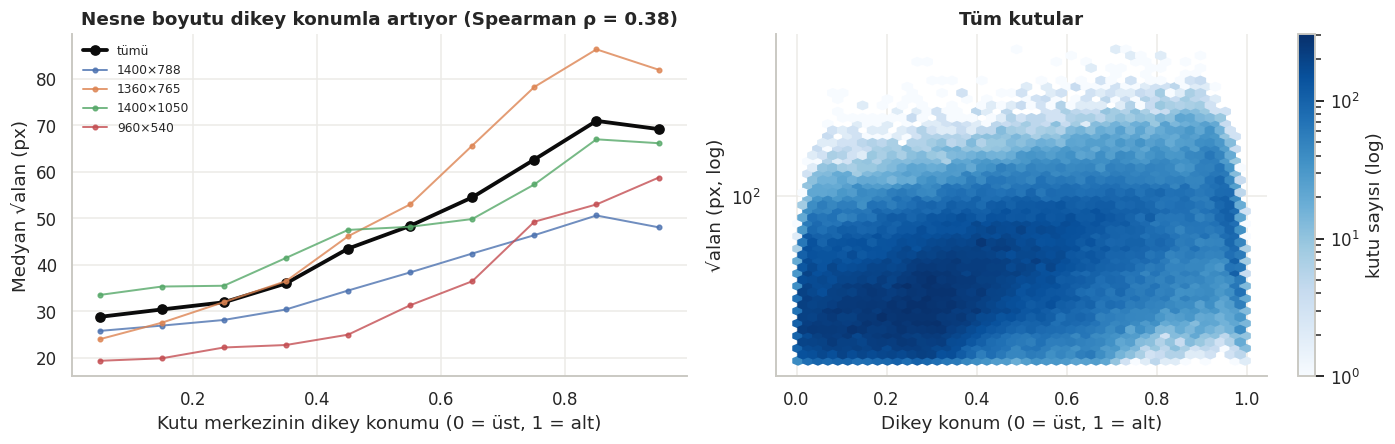

Üst %10'daki medyan kenar: 28.8 px  |  alt %10: 69.2 px  |  oran: 2.4×


In [10]:
ann["y_bin"] = pd.cut(ann["cy"], np.linspace(0, 1, 11), include_lowest=True)
centers = np.linspace(0.05, 0.95, 10)
rho = ann[["cy", "area"]].corr(method="spearman").iloc[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
overall = ann.groupby("y_bin", observed=False)["side"].median()
axes[0].plot(centers, overall.values, marker="o", linewidth=2.5, color="#0b0b0b", label="tümü")
for r in RES[:4]:
    s = ann[ann["resolution"] == r].groupby("y_bin", observed=False)["side"].median()
    axes[0].plot(centers, s.values, marker=".", linewidth=1.3, alpha=0.8, label=r)
axes[0].set_xlabel("Kutu merkezinin dikey konumu (0 = üst, 1 = alt)")
axes[0].set_ylabel("Medyan √alan (px)")
axes[0].set_title(f"Nesne boyutu dikey konumla artıyor (Spearman ρ = {rho:.2f})")
axes[0].legend(frameon=False, fontsize=8)

hb = axes[1].hexbin(ann["cy"], ann["side"], gridsize=45, bins="log", cmap="Blues", yscale="log", mincnt=1)
axes[1].set_xlabel("Dikey konum (0 = üst, 1 = alt)")
axes[1].set_ylabel("√alan (px, log)")
axes[1].set_title("Tüm kutular")
fig.colorbar(hb, ax=axes[1], label="kutu sayısı (log)")
plt.tight_layout()
plt.show()
print(f"Üst %10'daki medyan kenar: {overall.iloc[0]:.1f} px  |  alt %10: {overall.iloc[-1]:.1f} px  |  oran: {overall.iloc[-1] / overall.iloc[0]:.1f}×")

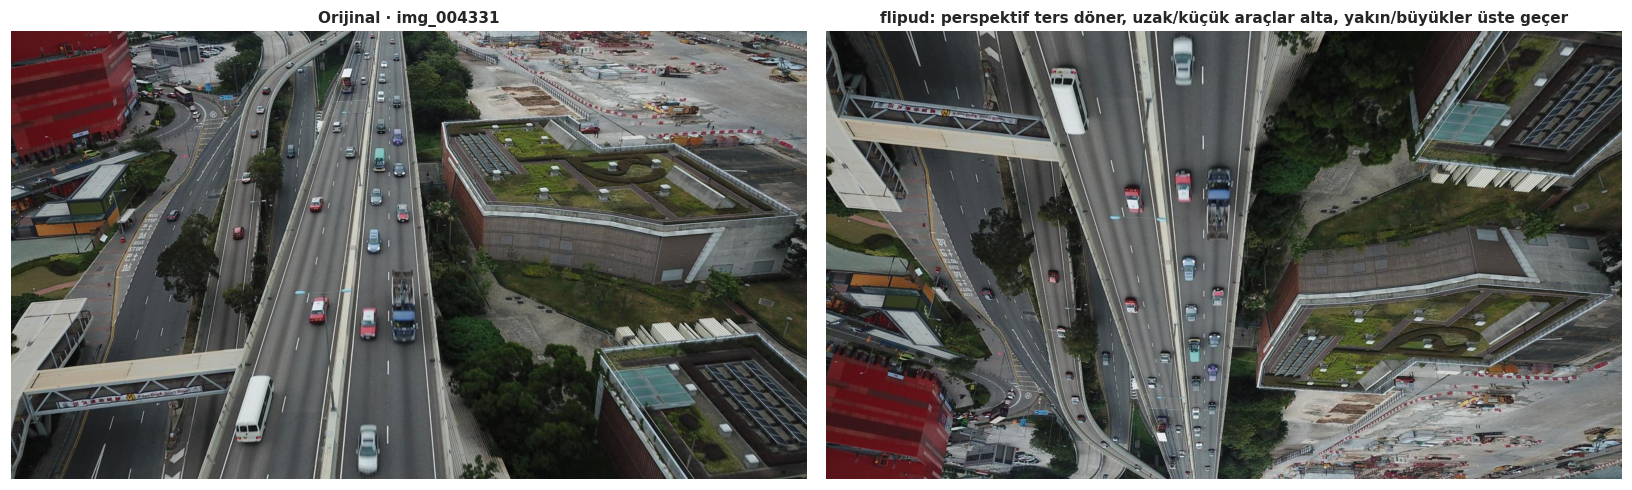

In [11]:
# Dikey çevirmenin ürettiği görüntü: eğik bir kare seçip yan yana gösterelim
cand = (ann[ann["resolution"] == "1400×788"].groupby("image_id")
        .agg(n=("label", "size"), rho=("cy", lambda s: 0)).query("n >= 25").index)
rng = np.random.default_rng(SEED)
pick = None
for i in rng.permutation(np.array(cand)):
    g = ann[ann["image_id"] == i]
    if g[["cy", "area"]].corr(method="spearman").iloc[0, 1] > 0.5:   # belirgin perspektifli kare
        pick = i
        break
img = np.asarray(Image.open(TRAIN_IMG_DIR / f"{pick}.jpg").convert("RGB"))
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
for ax, im, title in [(axes[0], img, f"Orijinal · {pick}"), (axes[1], img[::-1], "flipud: perspektif ters döner, uzak/küçük araçlar alta, yakın/büyükler üste geçer")]:
    ax.imshow(im)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

**Ne öğrendik?**
- Nesne boyutu görüntünün üstünden altına **yaklaşık 2–2,5 kat** artıyor. Eğik çekimin perspektif etkisi bu.
  01_eda'daki "nesneler merkezin üstünde yoğun" gözleminin nedeni de aynı: ufka yakın bölgede çok sayıda küçük araç var.
- **`flipud` kullanılmamalı** (Ultralytics varsayılanı zaten 0.0). Gerçekte karşılaşılmayacak bir geometri üretir. `fliplr=0.5` güvenli.
- Görüntünün **üst bölgesi** küçük nesnelerin yoğunlaştığı yer: SAHI tile'ları burada en çok kazanç sağlar.

## D. Küçük kutularda IoU hassasiyeti

Doğru tahmin için IoU ≥ 0,5 gerekiyor (BBM416 week10). Kenarı *s* olan kare bir kutu *d* px kayarsa:
- **Tek eksende:** IoU = (s−d)/(s+d) → eşik için **d ≤ s/3**
- **Çapraz (iki eksende birden):** IoU = (s−d)² / (2s² − (s−d)²) → eşik için **d ≤ s·(1 − √(2/3)) ≈ 0,18·s**

Yani 14 px'lik bir araçta çapraz 2,5 px'lik hata bile tahmini FP'ye çevirir.

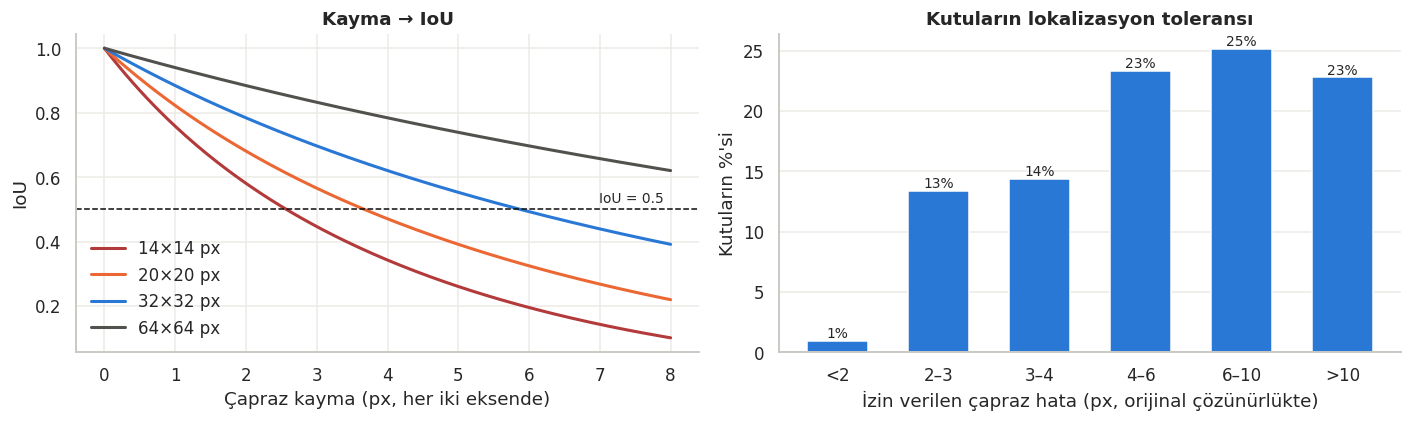

Toleransı < 3 px olan kutular: 14.3%  |  < 4 px: 28.7%


In [12]:
d = np.linspace(0, 8, 161)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for s, col in zip([14, 20, 32, 64], ["#b33a3a", "#eb6834", "#2a78d6", "#52514e"]):
    iou = np.clip(s - d, 0, None) ** 2 / (2 * s * s - np.clip(s - d, 0, None) ** 2)
    axes[0].plot(d, iou, linewidth=2, color=col, label=f"{s}×{s} px")
axes[0].axhline(0.5, color="#0b0b0b", linestyle="--", linewidth=1)
axes[0].text(7.9, 0.52, "IoU = 0.5", ha="right", fontsize=9)
axes[0].set_xlabel("Çapraz kayma (px, her iki eksende)")
axes[0].set_ylabel("IoU")
axes[0].set_title("Kayma → IoU")
axes[0].legend(frameon=False)

tol = ann["min_side"] * (1 - np.sqrt(2 / 3))
tb = pd.cut(tol, [0, 2, 3, 4, 6, 10, np.inf], labels=["<2", "2–3", "3–4", "4–6", "6–10", ">10"], right=False)
share = tb.value_counts(normalize=True).sort_index() * 100
axes[1].bar(share.index.astype(str), share.values, color="#2a78d6", width=0.6)
for i, v in enumerate(share.values):
    axes[1].text(i, v, f"{v:.0f}%", ha="center", va="bottom", fontsize=9)
axes[1].set_xlabel("İzin verilen çapraz hata (px, orijinal çözünürlükte)")
axes[1].set_ylabel("Kutuların %'si")
axes[1].set_title("Kutuların lokalizasyon toleransı")
axes[1].grid(axis="x", visible=False)
plt.tight_layout()
plt.show()
print(f"Toleransı < 3 px olan kutular: {(tol < 3).mean() * 100:.1f}%  |  < 4 px: {(tol < 4).mean() * 100:.1f}%")

**Ne öğrendik?**
- Kutuların önemli bir kısmında izin verilen hata **birkaç piksel**. Modelin sadece aracı *bulması* değil, sınırını **piksel hassasiyetinde** çizmesi gerekiyor.
- Görüntü küçültüldüğünde tolerans da aynı oranda küçülür (1400 px → 1280'de ×0,91; 640'ta ×0,46). Bu, resize analizinden bağımsız olarak
  **yüksek çözünürlük, SAHI ve stride-4 (P2) head** için ayrı bir gerekçe.
- Bu boyutta etiketleyici hatası da birkaç piksel olabilir. Küçük kutularda ulaşılabilecek AP'nin bir tavanı var.

## E. Resize analizi (düzeltilmiş)

01_eda Bölüm 11 büyütme yapılmadığını varsaydı: `scale = min(1, imgsz / uzun kenar)`. Ultralytics ise uzun kenarı **her iki yönde**
`imgsz`'ye getirir (eğitimde `load_image`, tahminde `LetterBox(scaleup=True)`). 960×540 gibi küçük görüntüler büyütülür.
Ayrıca test dağılımı farklı olduğu için sonuçları **test ağırlıklı** da hesaplıyoruz (her kutu, görüntüsünün çözünürlük ağırlığıyla).

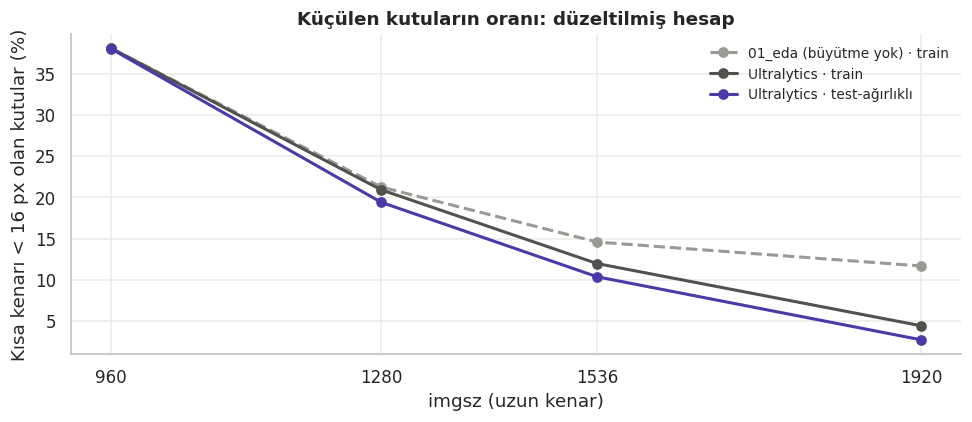

Kısa kenarı < 16 px olan kutular (%)


ölçekleme 01_eda (büyütme yok)          Ultralytics      
dağılım         test-ağırlıklı train test-ağırlıklı train
imgsz                                                    
960                      38.00 38.10          38.00 38.10
1280                     20.10 21.20          19.40 20.90
1536                     14.20 14.60          10.40 12.00
1920                     13.20 11.70           2.70  4.40

In [13]:
long_side = ann[["width", "height"]].max(axis=1)
w_box = ann["resolution"].map((p_test / p_train).fillna(0)).fillna(0)     # train → test ağırlığı (kutu düzeyi)
rows = []
for imgsz in [960, 1280, 1536, 1920]:
    for mode in ["01_eda (büyütme yok)", "Ultralytics"]:
        scale = np.minimum(1.0, imgsz / long_side) if mode.startswith("01") else imgsz / long_side
        ms = ann["min_side"] * scale
        for dist, wts in [("train", None), ("test-ağırlıklı", w_box)]:
            rows.append({"imgsz": imgsz, "ölçekleme": mode, "dağılım": dist,
                         "<8 px (%)": np.average(ms < 8, weights=wts) * 100,
                         "<16 px (%)": np.average(ms < 16, weights=wts) * 100})
rz = pd.DataFrame(rows)
piv = rz.pivot_table(index="imgsz", columns=["ölçekleme", "dağılım"], values="<16 px (%)").round(1)

fig, ax = plt.subplots(figsize=(9, 4))
styles = {("01_eda (büyütme yok)", "train"): ("#9a9994", "--"), ("Ultralytics", "train"): ("#52514e", "-"),
          ("Ultralytics", "test-ağırlıklı"): ("#4a3aa7", "-")}
for (mode, dist), (col, ls) in styles.items():
    s = rz[(rz["ölçekleme"] == mode) & (rz["dağılım"] == dist)]
    ax.plot(s["imgsz"], s["<16 px (%)"], marker="o", color=col, linestyle=ls, linewidth=2, label=f"{mode} · {dist}")
ax.set_xticks([960, 1280, 1536, 1920])
ax.set_xlabel("imgsz (uzun kenar)")
ax.set_ylabel("Kısa kenarı < 16 px olan kutular (%)")
ax.set_title("Küçülen kutuların oranı: düzeltilmiş hesap")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()
print("Kısa kenarı < 16 px olan kutular (%)")
piv

**Ne öğrendik?**
- Ultralytics'in büyütme davranışı küçük görüntülerde kaybı azaltıyor. 01_eda'nın tablosu bu grupları kötümser gösteriyordu.
- Ultralytics büyütmesi 1536–1920'de farkı büyütüyor: 1400 px'lik görüntüler büyütüldüğü için küçük kutu oranı hızla düşüyor.
- **Test ağırlıklı hesap train'e çok yakın, hatta biraz daha iyi.** Test gruplarının nesneleri orijinal pikselde daha küçük olsa da
  uzun kenarları 1400 px civarında. Train'deki 2000×1500 görüntüler ise çok daha fazla küçültülüyor ve bu grup testte yok. Yani
  "testte resize kaybı daha büyük" beklentisi **doğru değil**; zorluk resize'dan değil, nesnelerin kendisinin küçük olmasından geliyor (Bölüm D).
- Sonuç değişmiyor: **imgsz ≥ 1280 şart**. 1536'da kısa kenarı < 16 px olan kutular ~%10'a iniyor; bellek yeterse denenmeli, yoksa SAHI.
- Küçük not: Ultralytics augment açıkken küçültmeyi `INTER_LINEAR` ile yapıyor, bu da aliasing'e yol açabilir (AIN431 week-4, BBM416 week4).
  Görüntüleri önceden `INTER_AREA` ile hedef boyuta indirip diske yazmak küçük bir iyileştirme olabilir. Düşük öncelikli.

## F. Aydınlatma: train ve test

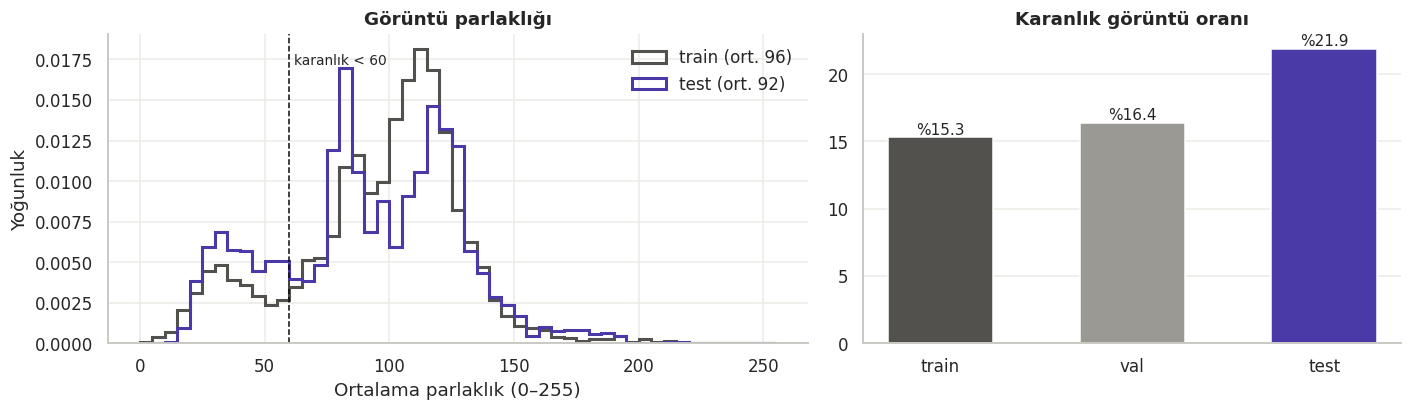

split,test,train
resolution,,
1400×788,45.10,18.30
1360×765,2.30,2.80
1400×1050,8.40,24.80
960×540,3.90,11.20
1916×1078,0.00,0.20
1920×1080,2.00,5.30
2000×1500,NaN,10.10


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.9), gridspec_kw={"width_ratios": [1.3, 1]})
bins = np.linspace(0, 255, 52)
for sname in ["train", "test"]:
    b = meta[meta["split"] == sname]["brightness"]
    axes[0].hist(b, bins=bins, density=True, histtype="step", linewidth=2, color=SPLIT_COLORS[sname], label=f"{sname} (ort. {b.mean():.0f})")
axes[0].axvline(DARK_THR, color="#0b0b0b", linestyle="--", linewidth=1)
axes[0].text(DARK_THR + 2, axes[0].get_ylim()[1] * 0.9, f"karanlık < {DARK_THR}", fontsize=9)
axes[0].set_xlabel("Ortalama parlaklık (0–255)")
axes[0].set_ylabel("Yoğunluk")
axes[0].set_title("Görüntü parlaklığı")
axes[0].legend(frameon=False)

dark = meta.assign(dark=meta["brightness"] < DARK_THR).groupby("subset")["dark"].mean().reindex(["train", "val", "test"]) * 100
axes[1].bar(dark.index, dark.values, color=[SPLIT_COLORS[s] for s in dark.index], width=0.55)
for i, v in enumerate(dark.values):
    axes[1].text(i, v, f"%{v:.1f}", ha="center", va="bottom", fontsize=10)
axes[1].set_title("Karanlık görüntü oranı")
axes[1].grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

dark_by_res = (meta.assign(dark=meta["brightness"] < DARK_THR)
               .pivot_table(index="resolution", columns="split", values="dark", aggfunc="mean").reindex(RES) * 100)
dark_by_res.round(1)

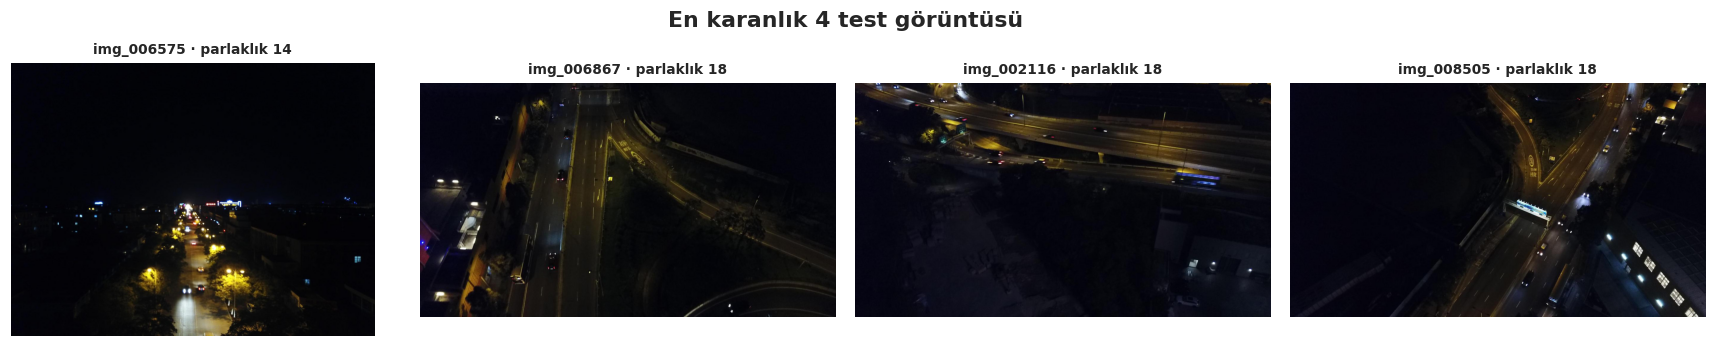

In [15]:
darkest = meta[meta["split"] == "test"].nsmallest(4, "brightness")
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, r in zip(axes, darkest.itertuples()):
    ax.imshow(Image.open(TEST_IMG_DIR / f"{r.image_id}.jpg"))
    ax.set_title(f"{r.image_id} · parlaklık {r.brightness:.0f}", fontsize=9)
    ax.axis("off")
fig.suptitle("En karanlık 4 test görüntüsü", fontweight="bold")
plt.tight_layout()
plt.show()

**Ne öğrendik?**
- Test, train'e göre **daha karanlık**. Fark neredeyse tamamen **1400×788** grubundan geliyor: bu grupta karanlık kare oranı train'de ~%18, testte ~%45.
- Bu yüzden val ağırlıkları çözünürlük × aydınlatma katmanlarıyla hesaplandı (Bölüm B).
- `hsv_v` augmentation'ı varsayılanın (0,4) biraz üstüne çıkarmak düşünülebilir. Val'de `is_dark` alt kümesinin AP'si ayrıca izlenmeli.

## G. Sızma (leakage) kontrolü

Drone verilerinde aynı sahneden ardışık kareler sık görülür. Bunlar train ile val arasında bölünürse val skoru şişer.
Kontrol için **dHash** kullanıyoruz: görüntü 9×8 griye küçültülür, komşu piksel karşılaştırmalarından 64 bit elde edilir.
İki özet arasındaki **Hamming mesafesi** ≤ 4 ise kareler neredeyse aynı, ≤ 8 ise çok benzer kabul edilir.

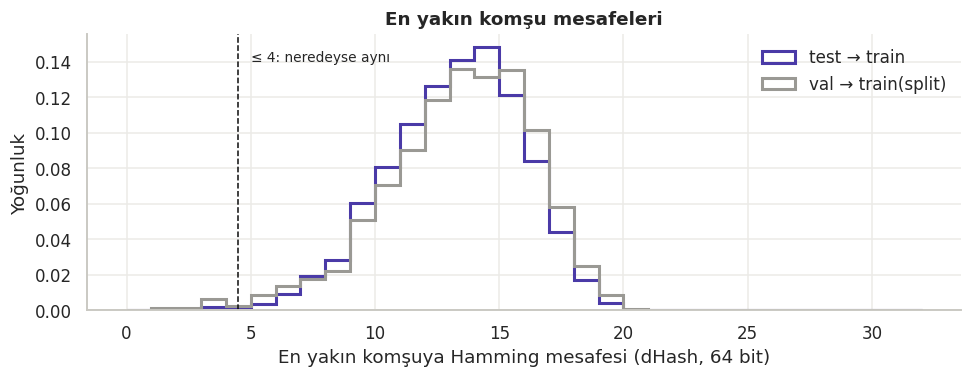

,test → train(tümü),val → train(split),train → train
mesafe ≤ 4 (%),0.57,1.16,1.44
mesafe ≤ 8 (%),6.66,7.42,9.16
medyan mesafe,13.00,13.00,13.00


In [16]:
H = np.array([int(h, 16) for h in meta["dhash"]], dtype=np.uint64)
POP = np.array([bin(i).count("1") for i in range(256)], dtype=np.uint8)


def nearest_dist(a_idx, b_idx, exclude_self=False, chunk=512):
    A, B = H[a_idx], H[b_idx]
    best = np.full(len(A), 99, dtype=np.int16)
    arg = np.zeros(len(A), dtype=np.int64)
    for s in range(0, len(A), chunk):
        x = A[s:s + chunk, None] ^ B[None, :]
        dist = POP[x.view(np.uint8).reshape(*x.shape, 8)].sum(-1).astype(np.int16)
        if exclude_self:
            ii = np.arange(s, min(s + chunk, len(A)))
            dist[ii - s, ii] = 99
        best[s:s + chunk] = dist.min(1)
        arg[s:s + chunk] = dist.argmin(1)
    return best, np.asarray(b_idx)[arg]


idx = {k: np.where(meta["subset"] == k)[0] for k in ["train", "val", "test"]}
train_all_idx = np.where(meta["split"] == "train")[0]
d_test, nn_test = nearest_dist(idx["test"], train_all_idx)
d_val, nn_val = nearest_dist(idx["val"], idx["train"])
d_tt, _ = nearest_dist(train_all_idx, train_all_idx, exclude_self=True)

leak = pd.DataFrame({
    "test → train(tümü)": [np.mean(d_test <= 4) * 100, np.mean(d_test <= 8) * 100, np.median(d_test)],
    "val → train(split)": [np.mean(d_val <= 4) * 100, np.mean(d_val <= 8) * 100, np.median(d_val)],
    "train → train": [np.mean(d_tt <= 4) * 100, np.mean(d_tt <= 8) * 100, np.median(d_tt)],
}, index=["mesafe ≤ 4 (%)", "mesafe ≤ 8 (%)", "medyan mesafe"])

fig, ax = plt.subplots(figsize=(9, 3.6))
b = np.arange(0, 33)
for arr, lab, col in [(d_test, "test → train", SPLIT_COLORS["test"]), (d_val, "val → train(split)", SPLIT_COLORS["val"])]:
    ax.hist(arr, bins=b, density=True, histtype="step", linewidth=2, color=col, label=lab)
ax.axvline(4.5, color="#0b0b0b", linestyle="--", linewidth=1)
ax.text(5, ax.get_ylim()[1] * 0.9, "≤ 4: neredeyse aynı", fontsize=9)
ax.set_xlabel("En yakın komşuya Hamming mesafesi (dHash, 64 bit)")
ax.set_ylabel("Yoğunluk")
ax.set_title("En yakın komşu mesafeleri")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
leak.round(2)

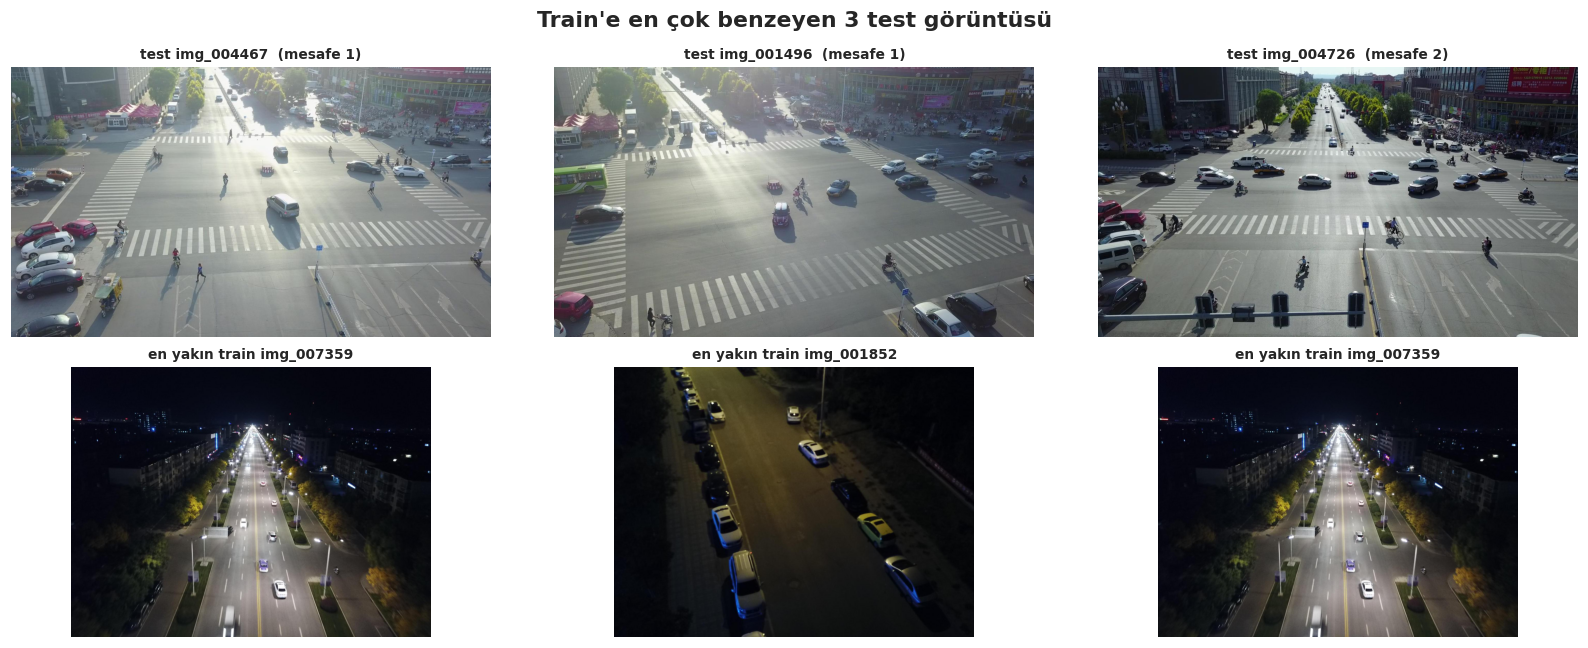

In [17]:
order = np.argsort(d_test)[:3]
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for col, k in enumerate(order):
    t_id, n_id = meta.iloc[idx["test"][k]]["image_id"], meta.iloc[nn_test[k]]["image_id"]
    axes[0, col].imshow(Image.open(TEST_IMG_DIR / f"{t_id}.jpg"))
    axes[0, col].set_title(f"test {t_id}  (mesafe {d_test[k]})", fontsize=9)
    axes[1, col].imshow(Image.open(TRAIN_IMG_DIR / f"{n_id}.jpg"))
    axes[1, col].set_title(f"en yakın train {n_id}", fontsize=9)
for ax in axes.flat:
    ax.axis("off")
fig.suptitle("Train'e en çok benzeyen 3 test görüntüsü", fontweight="bold")
plt.tight_layout()
plt.show()

**Ne öğrendik?**
- Neredeyse aynı kare oranı **çok düşük**: val ile train arasında sızma val skorunu anlamlı biçimde şişirmiyor.
- **Rastgele split geçerli**, sahne bazlı yeniden bölmeye gerek yok. Bu, 01_eda'daki "split sağlam" kararının eksik kanıtını tamamlıyor.
- Test ile train arasında da çok az benzer kare var. Model testte, ezberlenmiş karelerden değil, gerçekten yeni sahnelerden tahmin yapacak.

## H. Etiket tutarlılığı

01_eda birebir tekrar eden 1 satır buldu. Burada **neredeyse üst üste binen kutuları** (IoU > 0,8) arıyoruz:
aynı sınıftaysa çift etiket, farklı sınıftaysa **çelişkili etiket** (aynı araç iki sınıfla etiketlenmiş).

In [18]:
def overlap_pairs(g, thr=0.8):
    B = g[["x", "y", "w", "h"]].to_numpy(float)
    L = g["label"].to_numpy()
    out = []
    for i in range(len(B) - 1):
        ious = _iou_one_to_many(B[i], B[i + 1:])
        for j in np.where(ious > thr)[0]:
            out.append((g.index[i], g.index[i + 1 + j], L[i], L[i + 1 + j], ious[j]))
    return out


pairs = pd.DataFrame([p for _, g in ann.groupby("image_id") for p in overlap_pairs(g)],
                     columns=["i", "j", "a", "b", "iou"])
pairs["tür"] = np.where(pairs["a"] == pairs["b"], "aynı sınıf (çift etiket)", "farklı sınıf (çelişki)")
summary = pairs.groupby("tür").size().to_frame("çift sayısı")
summary.loc["toplam kutu içindeki payı (%)"] = len(pairs) / len(ann) * 100
display(summary)
conf = pairs[pairs["a"] != pairs["b"]]
conf.apply(lambda r: " ↔ ".join(sorted([r["a"], r["b"]])), axis=1).value_counts().to_frame("çelişki")

,çift sayısı
tür,
aynı sınıf (çift etiket),69.00
farklı sınıf (çelişki),6.00
toplam kutu içindeki payı (%),0.05


,çelişki
car ↔ van,6


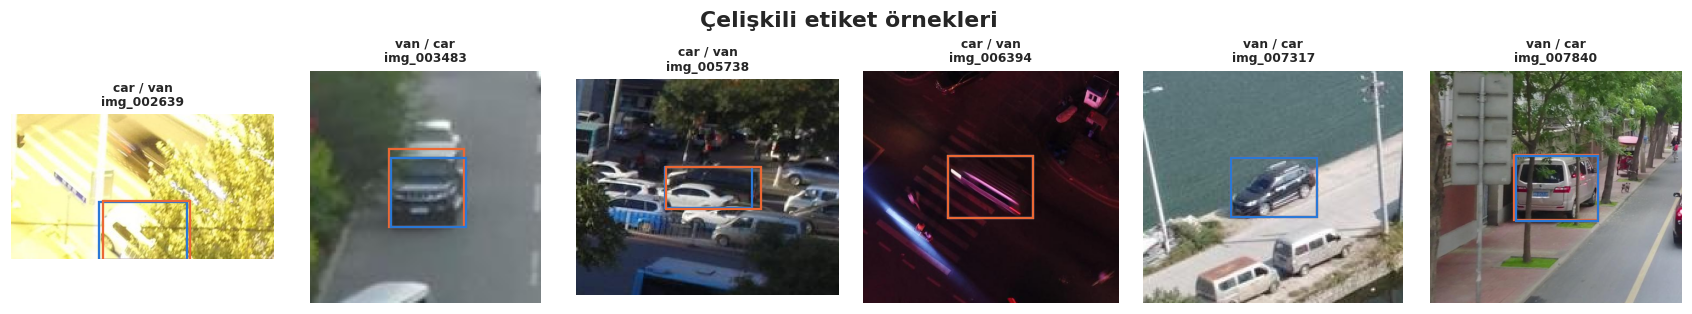

In [19]:
show = conf.head(6)
if len(show):
    fig, axes = plt.subplots(1, len(show), figsize=(2.6 * len(show), 2.9))
    axes = np.atleast_1d(axes)
    for ax, r in zip(axes, show.itertuples()):
        a, b = ann.loc[r.i], ann.loc[r.j]
        img = Image.open(TRAIN_IMG_DIR / f"{a['image_id']}.jpg").convert("RGB")
        pad = max(a["w"], a["h"])
        box = (max(0, a["x"] - pad), max(0, a["y"] - pad), min(a["width"], a["x"] + a["w"] + pad), min(a["height"], a["y"] + a["h"] + pad))
        ax.imshow(img.crop(box))
        for bb in (a, b):
            ax.add_patch(mpatches.Rectangle((bb["x"] - box[0], bb["y"] - box[1]), bb["w"], bb["h"], fill=False,
                                            edgecolor=CLASS_COLORS[bb["label"]], linewidth=1.5))
        ax.set_title(f"{a['label']} / {b['label']}\n{a['image_id']}", fontsize=8)
        ax.axis("off")
    fig.suptitle("Çelişkili etiket örnekleri", fontweight="bold")
    plt.tight_layout()
    plt.show()

**Ne öğrendik?**
- Çift ve çelişkili etiketler **toplam kutuların binde birinin altında**. Temizlemeye değmez, ama car↔van çelişkisinin varlığı
  bu iki sınıfın etiketleyiciler için de zor olduğunu doğruluyor. Car–van karışması muhtemelen en büyük hata kaynağı olacak.

## I. Bulgular → Kararlar (01_eda tablosuna ek)

In [20]:
bus_788 = src.loc["bus", "1400×788"]
decisions = pd.DataFrame([
    ["12", "Sınıf karışımı çözünürlüğe bağlı",
     f"1400×788'de bus %{mix.loc['1400×788', 'bus']:.1f}, van %{mix.loc['1400×788', 'van']:.1f}; train otobüslerinin %{bus_788:.0f}'i bu gruptan; testin %{p_test['1400×788'] * 100:.0f}'i",
     "1400×788 görüntüleri oversample et (copy-paste yerine); karanlık 1400×788 karelerini de dahil et. Beklenen test bus payı ≈ train × %.1f." % expected.loc["bus", "oran (test/train)"]],
    ["13", "Val çözünürlük dağılımı testi temsil etmiyor",
     f"Çözünürlük × aydınlatma katmanlı önem ağırlıkları, ESS = {ess:.0f}",
     "Her deneyde iki skor: standart val mAP + test-ağırlıklı val mAP (val_test_weights.csv). Alt kümeler: 1400×788, karanlık."],
    ["14", "Perspektif", f"Medyan kenar üstten alta {overall.iloc[-1] / overall.iloc[0]:.1f}×, ρ = {rho:.2f}",
     "flipud = 0, fliplr = 0.5. Üst bölge küçük nesneler için SAHI."],
    ["15", "Küçük kutularda IoU hassas", f"Toleransı < 3 px olan kutular %{(tol < 3).mean() * 100:.0f}",
     "Yüksek imgsz, SAHI, P2 head denemesi. Lokalizasyon kaybına dikkat."],
    ["16", "Resize kaybı: test ≈ train", "Ultralytics büyütmesiyle: imgsz 1280'de <16 px kutu ~%19–21, 1536'da ~%10–12",
     "imgsz ≥ 1280 şart; 1536 bellek yeterse, değilse SAHI."],
    ["17", "Test daha karanlık", f"Karanlık görüntü: train %{dark['train']:.1f} → test %{dark['test']:.1f}; 1400×788'de %{img788['is_dark'].mean() * 100:.0f} → %{t788['is_dark'].mean() * 100:.0f}",
     "hsv_v biraz artırılabilir; is_dark ve karanlık 1400×788 alt kümelerinin AP'si izlenecek."],
    ["18", "Sızma yok", f"val→train mesafe ≤ 4: %{np.mean(d_val <= 4) * 100:.1f}",
     "Rastgele split geçerli; sahne bazlı split gereksiz."],
    ["19", "Etiket çelişkisi nadir", f"{len(conf)} car↔van vb. çelişkili çift",
     "Temizlik yok. Car–van karışıklığı confusion matrix'te izlenecek."],
], columns=["#", "Bulgu", "Sayı", "Karar"])
with pd.option_context("display.max_colwidth", None):
    display(decisions.set_index("#"))

,Bulgu,Sayı,Karar
#,,,
12,Sınıf karışımı çözünürlüğe bağlı,"1400×788'de bus %10.6, van %19.7; train otobüslerinin %60'i bu gruptan; testin %44'i",1400×788 görüntüleri oversample et (copy-paste yerine); karanlık 1400×788 karelerini de dahil et. Beklenen test bus payı ≈ train × 1.5.
13,Val çözünürlük dağılımı testi temsil etmiyor,"Çözünürlük × aydınlatma katmanlı önem ağırlıkları, ESS = 602","Her deneyde iki skor: standart val mAP + test-ağırlıklı val mAP (val_test_weights.csv). Alt kümeler: 1400×788, karanlık."
14,Perspektif,"Medyan kenar üstten alta 2.4×, ρ = 0.38","flipud = 0, fliplr = 0.5. Üst bölge küçük nesneler için SAHI."
15,Küçük kutularda IoU hassas,Toleransı < 3 px olan kutular %14,"Yüksek imgsz, SAHI, P2 head denemesi. Lokalizasyon kaybına dikkat."
16,Resize kaybı: test ≈ train,"Ultralytics büyütmesiyle: imgsz 1280'de <16 px kutu ~%19–21, 1536'da ~%10–12","imgsz ≥ 1280 şart; 1536 bellek yeterse, değilse SAHI."
17,Test daha karanlık,Karanlık görüntü: train %15.3 → test %21.9; 1400×788'de %18 → %45,hsv_v biraz artırılabilir; is_dark ve karanlık 1400×788 alt kümelerinin AP'si izlenecek.
18,Sızma yok,val→train mesafe ≤ 4: %1.2,Rastgele split geçerli; sahne bazlı split gereksiz.
19,Etiket çelişkisi nadir,6 car↔van vb. çelişkili çift,Temizlik yok. Car–van karışıklığı confusion matrix'te izlenecek.


**Kod tarafına aktarım**
1. **Değerlendirici:** Bölüm B'deki `weighted_map` fonksiyonu + `furkan/val_test_weights.csv`. Her deneyde raporlanacaklar:
   `mAP (val)`, `mAP (test-ağırlıklı, weight sütunu)`, sınıf bazında AP, ayrıca `is_1400x788` ve `is_dark` alt kümeleri.
2. **Augmentation (Ultralytics):** `fliplr=0.5`, `flipud=0.0`, `hsv_v≈0.5`, mosaic açık.
3. **Örnekleme:** eğitim listesinde 1400×788 görüntüleri ×2 tekrarla (karanlıklar dahil). Etkisini test-ağırlıklı val mAP ile ölç.
4. **Çözünürlük:** `imgsz=1280` ile başla, SAHI ve 1536 denemeleri test-ağırlıklı metrikle karşılaştırılsın.